In [7]:
import sys
import herbie
import xarray as xr
import zarr as za
from herbie import Herbie
H = Herbie('2024-01-01', model='urma')
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
print("\n✓ STACK READY!!!!")

✅ Found ┊ model=urma ┊ product=anl ┊ 2024-Jan-01 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ None

✓ STACK READY!!!!


In [8]:
YEAR = '2022_full'
INPUT = f'02_URMA_COUNTY/URMA_COUNTY_{YEAR}.zarr'
#OUTPUT = f'03_URMA_FEAT_ENG/URMA_FEAT_ENG_{YEAR}.zarr'
#PARQUET = f'03_URMA_FEAT_ENG_PARQ/URMA_FEAT_ENG_PARQ_{YEAR}.parquet'

In [9]:
directory = f"{INPUT}"
ds = xr.open_zarr(INPUT, consolidated=False, create_default_indexes=False)
ds

<xarray.Dataset> Size: 3GB
Dimensions:          (date: 365, y: 535, x: 457)
Coordinates:
    date             (date) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    county           (y, x) object 2MB dask.array<chunksize=(535, 457), meta=np.ndarray>
    longitude        (y, x) float64 2MB dask.array<chunksize=(134, 229), meta=np.ndarray>
    latitude         (y, x) float64 2MB dask.array<chunksize=(535, 457), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    cloud_cover_pct  (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    spfh_peak_kgkg   (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    t2m_max_k        (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    dpt_morning_k    (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    t2m_min_k        (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    dpt_afternoon_k  (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    wind_low_ms      (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>
    wind_peak_ms     (date, y, x) float32 357MB dask.array<chunksize=(1, 535, 457), meta=np.ndarray>

In [10]:
ds.date.min().compute()

<xarray.DataArray 'date' ()> Size: 8B
array('2022-01-01T00:00:00.000000000', dtype='datetime64[ns]')

In [11]:
ds.date.max().compute()

<xarray.DataArray 'date' ()> Size: 8B
array('2022-12-31T00:00:00.000000000', dtype='datetime64[ns]')

In [12]:
print("temp:",ds["t2m_max_k"].dims, ds["t2m_max_k"].shape)
print("county:",ds["county"].dims, ds["county"].shape)

temp: ('date', 'y', 'x') (365, 535, 457)
county: ('y', 'x') (535, 457)


In [13]:
unique_counties = np.unique(ds.county.values)
unique_counties

array(['Alameda', 'Alpine', 'Amador', 'Butte', 'Calaveras', 'Colusa',
       'Contra Costa', 'Del Norte', 'El Dorado', 'Fresno', 'Glenn',
       'Humboldt', 'Imperial', 'Inyo', 'Kern', 'Kings', 'Lake', 'Lassen',
       'Los Angeles', 'Madera', 'Marin', 'Mariposa', 'Mendocino',
       'Merced', 'Modoc', 'Mono', 'Monterey', 'Napa', 'Nevada', 'Orange',
       'Outside_CA', 'Placer', 'Plumas', 'Riverside', 'Sacramento',
       'San Benito', 'San Bernardino', 'San Diego', 'San Francisco',
       'San Joaquin', 'San Luis Obispo', 'San Mateo', 'Santa Barbara',
       'Santa Clara', 'Santa Cruz', 'Shasta', 'Sierra', 'Siskiyou',
       'Solano', 'Sonoma', 'Stanislaus', 'Sutter', 'Tehama', 'Trinity',
       'Tulare', 'Tuolumne', 'Ventura', 'Yolo', 'Yuba'], dtype=object)

In [14]:
print("ds dims:", ds.dims)
print("t2m_max_k dims:", ds["t2m_max_k"].dims)
print("county dims:", ds["county"].dims)

ds dims: FrozenMappingWarningOnValuesAccess({'date': 365, 'y': 535, 'x': 457})
t2m_max_k dims: ('date', 'y', 'x')
county dims: ('y', 'x')


In [15]:
county = ds['county']

In [16]:
tmax = ds["t2m_max_k"]
county = ds["county"].load()



In [17]:
tmax_date = tmax.stack(cell=("y","x"))
county1 = county.stack(cell=("y","x"))


tmax_date = tmax_date.assign_coords(county=("cell",county1.data))


county_tmax_day_mean = (
    tmax_date
    .where(tmax_date["county"].notnull())
    .groupby("county")
    .mean(dim="cell")    
)

county_tmax_day_mean

<xarray.DataArray 't2m_max_k' (date: 365, county: 59)> Size: 86kB
dask.array<transpose, shape=(365, 59), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
    date     (date) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * county   (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [18]:
print(county_tmax_day_mean,)

<xarray.DataArray 't2m_max_k' (date: 365, county: 59)> Size: 86kB
dask.array<transpose, shape=(365, 59), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
    date     (date) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * county   (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid

In [19]:
county_tmax_day_mean.isel(date=0).compute()

<xarray.DataArray 't2m_max_k' (county: 59)> Size: 236B
array([282.88156, 271.26895, 279.06943, 281.03366, 278.80865, 283.1774 ,
       284.0258 , 277.83105, 276.2024 , 278.77078, 282.31976, 278.12314,
       291.4477 , 280.5426 , 280.3621 , 283.7676 , 279.46402, 271.63553,
       285.03976, 278.69702, 284.05154, 276.95282, 279.47012, 283.19138,
       271.25128, 273.05124, 282.6547 , 283.4327 , 276.0294 , 287.8176 ,
       279.95706, 276.63547, 273.03568, 287.8662 , 284.46286, 280.24002,
       285.30396, 286.39124, 284.8628 , 283.96432, 282.82498, 284.29068,
       284.15988, 281.5482 , 283.94193, 277.04086, 272.38516, 272.6774 ,
       285.06628, 283.44748, 282.39316, 284.18842, 279.997  , 274.25058,
       277.5651 , 274.23068, 284.419  , 284.0034 , 282.3584 ],
      dtype=float32)
Coordinates:
  * county   (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
    date     datetime64[ns] 8B 2022-01-01
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [20]:
tmin = ds['t2m_min_k']

In [21]:
tmin_date = tmin.stack(cell=("y","x"))

tmin_date = tmin_date.assign_coords(county=("cell",county1.data))


county_tmin_day_mean = (
    tmin_date
    .where(tmin_date["county"].notnull())
    .groupby("county")
    .mean(dim="cell")     # ✅ only space
)

county_tmin_day_mean

<xarray.DataArray 't2m_min_k' (date: 365, county: 59)> Size: 86kB
dask.array<transpose, shape=(365, 59), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
    date     (date) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * county   (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Attributes: (12/39)
    GRIB_paramId:                             3016
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            min
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Minimum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [22]:
county_tmin_day_mean.compute()

<xarray.DataArray 't2m_min_k' (date: 365, county: 59)> Size: 86kB
array([[274.86087, 258.29147, 269.6786 , ..., 275.79767, 275.57535,
        272.3536 ],
       [274.03027, 264.4363 , 272.4187 , ..., 277.02313, 272.3867 ,
        272.33994],
       [278.22678, 266.64536, 273.7694 , ..., 276.41812, 275.8894 ,
        274.66687],
       ...,
       [280.67947, 265.6341 , 276.2223 , ..., 280.9212 , 279.22287,
        278.05948],
       [283.11053, 272.26373, 279.26697, ..., 282.20193, 282.1422 ,
        280.9294 ],
       [286.0549 , 273.54596, 282.83145, ..., 283.0091 , 285.5192 ,
        284.26923]], shape=(365, 59), dtype=float32)
Coordinates:
    date     (date) datetime64[ns] 3kB 2022-01-01 2022-01-02 ... 2022-12-31
  * county   (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Attributes: (12/39)
    GRIB_paramId:                             3016
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            min
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Minimum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [23]:
(county_tmin_day_mean-273).mean().compute()

<xarray.DataArray 't2m_min_k' ()> Size: 4B
array(9.089334, dtype=float32)
Attributes: (12/39)
    GRIB_paramId:                             3016
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            min
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Minimum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [24]:
(county_tmax_day_mean-273).mean().compute()

<xarray.DataArray 't2m_max_k' ()> Size: 4B
array(20.780964, dtype=float32)
Attributes: (12/39)
    GRIB_paramId:                             3015
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3744965
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            max
    ...                                       ...
    GRIB_stepRange:                           0-12
    GRIB_units:                               K
    long_name:                                Maximum temperature
    units:                                    K
    standard_name:                            unknown
    grid_mapping:                             gribfile_projection

In [25]:
## HDD/CDD CALC

In [26]:
import xarray as xr

# rename these to your actual objects
tmax = county_tmax_day_mean
tmin = county_tmin_day_mean

# standardize dim order (works if dims are either order)
tmax = tmax.transpose("date", "county")
tmin = tmin.transpose("date", "county")

feat = xr.Dataset({
    "tmax_k": tmax,
    "tmin_k": tmin,
})

feat["tavg_k"] = (feat["tmax_k"] + feat["tmin_k"]) / 2
feat["trange_k"] = feat["tmax_k"] - feat["tmin_k"]


In [27]:
base_k = (65 - 32) * 5/9 + 273.15  # 291.483333...

In [28]:
feat["cdd65"] = xr.where(feat["tavg_k"] > base_k, feat["tavg_k"] - base_k, 0.0)
feat["hdd65"] = xr.where(feat["tavg_k"] < base_k, base_k - feat["tavg_k"], 0.0)

In [29]:
(feat[["tavg_k", "cdd65", "hdd65"]]
 .isel(county=slice(0,5), date=slice(0,5))
 .compute())

<xarray.Dataset> Size: 380B
Dimensions:  (date: 5, county: 5)
Coordinates:
    date     (date) datetime64[ns] 40B 2022-01-01 2022-01-02 ... 2022-01-05
  * county   (county) object 40B 'Alameda' 'Alpine' 'Amador' 'Butte' 'Calaveras'
Data variables:
    tavg_k   (date, county) float32 100B 278.9 264.8 274.4 ... 281.3 281.5 281.8
    cdd65    (date, county) float32 100B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    hdd65    (date, county) float32 100B 12.61 26.7 17.11 ... 10.18 9.943 9.706

In [30]:
feat

<xarray.Dataset> Size: 520kB
Dimensions:   (date: 365, county: 59)
Coordinates:
    date      (date) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * county    (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Data variables:
    tmax_k    (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tmin_k    (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tavg_k    (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    trange_k  (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    cdd65     (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    hdd65     (date, county) float32 86kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [31]:
feat = feat.chunk({"date": 30, "county": 59})
feat

<xarray.Dataset> Size: 520kB
Dimensions:   (date: 365, county: 59)
Coordinates:
    date      (date) datetime64[ns] 3kB dask.array<chunksize=(30,), meta=np.ndarray>
  * county    (county) object 472B 'Alameda' 'Alpine' 'Amador' ... 'Yolo' 'Yuba'
Data variables:
    tmax_k    (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    tmin_k    (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    tavg_k    (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    trange_k  (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    cdd65     (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    hdd65     (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>

In [32]:
feat["cdd75"] = xr.where(feat["tavg_k"] > (75-32)*5/9+273.15,
                         feat["tavg_k"] - ((75-32)*5/9+273.15),
                         0)

In [33]:
### Other Weather Features

In [34]:
def county_mean(da, county):
    """
    da: DataArray with dims (date, y, x)
    county: DataArray with dims (y, x), already loaded
    """
    da1 = da.stack(cell=("y", "x"))
    county1 = county.stack(cell=("y", "x"))
    da1 = da1.assign_coords(county=("cell", county1.data))

    return ( 
        da1
        .where(da1["county"].notnull())
        .groupby("county")
        .mean(dim="cell")
    )


In [35]:
feat["cloud_cover_pct_mean"] = county_mean(ds["cloud_cover_pct"], county)
feat["dpt_morning_k_mean"] = county_mean(ds["dpt_morning_k"], county)
feat["dpt_afternoon_k_mean"] = county_mean(ds["dpt_afternoon_k"], county)
feat["spfh_peak_kgkg_mean"] = county_mean(ds["spfh_peak_kgkg"], county)
feat["wind_low_ms_mean"] = county_mean(ds["wind_low_ms"], county)
feat["wind_peak_ms_mean"] = county_mean(ds["wind_peak_ms"], county)

In [36]:
feat = feat.chunk({"date": 30, "county": 59})
feat

<xarray.Dataset> Size: 1MB
Dimensions:               (date: 365, county: 59)
Coordinates:
    date                  (date) datetime64[ns] 3kB dask.array<chunksize=(30,), meta=np.ndarray>
  * county                (county) object 472B 'Alameda' 'Alpine' ... 'Yuba'
Data variables: (12/13)
    tmax_k                (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    tmin_k                (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    tavg_k                (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    trange_k              (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    cdd65                 (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    hdd65                 (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    ...                    ...
    cloud_cover_pct_mean  (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    dpt_morning_k_mean    (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    dpt_afternoon_k_mean  (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    spfh_peak_kgkg_mean   (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    wind_low_ms_mean      (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>
    wind_peak_ms_mean     (date, county) float32 86kB dask.array<chunksize=(30, 59), meta=np.ndarray>

In [37]:
def dataset_minmax_df(ds):
    mins = ds.min().compute()
    maxs = ds.max().compute()

    rows = []

    for var in ds.data_vars:
        rows.append({
            "variable": var,
            "min": round(float(mins[var]), 4),
            "max": round(float(maxs[var]), 4)
        })

    return pd.DataFrame(rows)

In [38]:
dataset_minmax_df(feat)

,variable,min,max
0,tmax_k,264.4911,318.5015
1,tmin_k,255.4692,304.2109
2,tavg_k,260.4494,310.7296
3,trange_k,-0.0518,23.7916
4,cdd65,0.0000,19.2462
5,hdd65,0.0000,31.0339
6,cdd75,0.0000,13.6907
7,cloud_cover_pct_mean,0.0000,100.0000
8,dpt_morning_k_mean,246.3214,297.6593
9,dpt_afternoon_k_mean,252.6913,295.6598


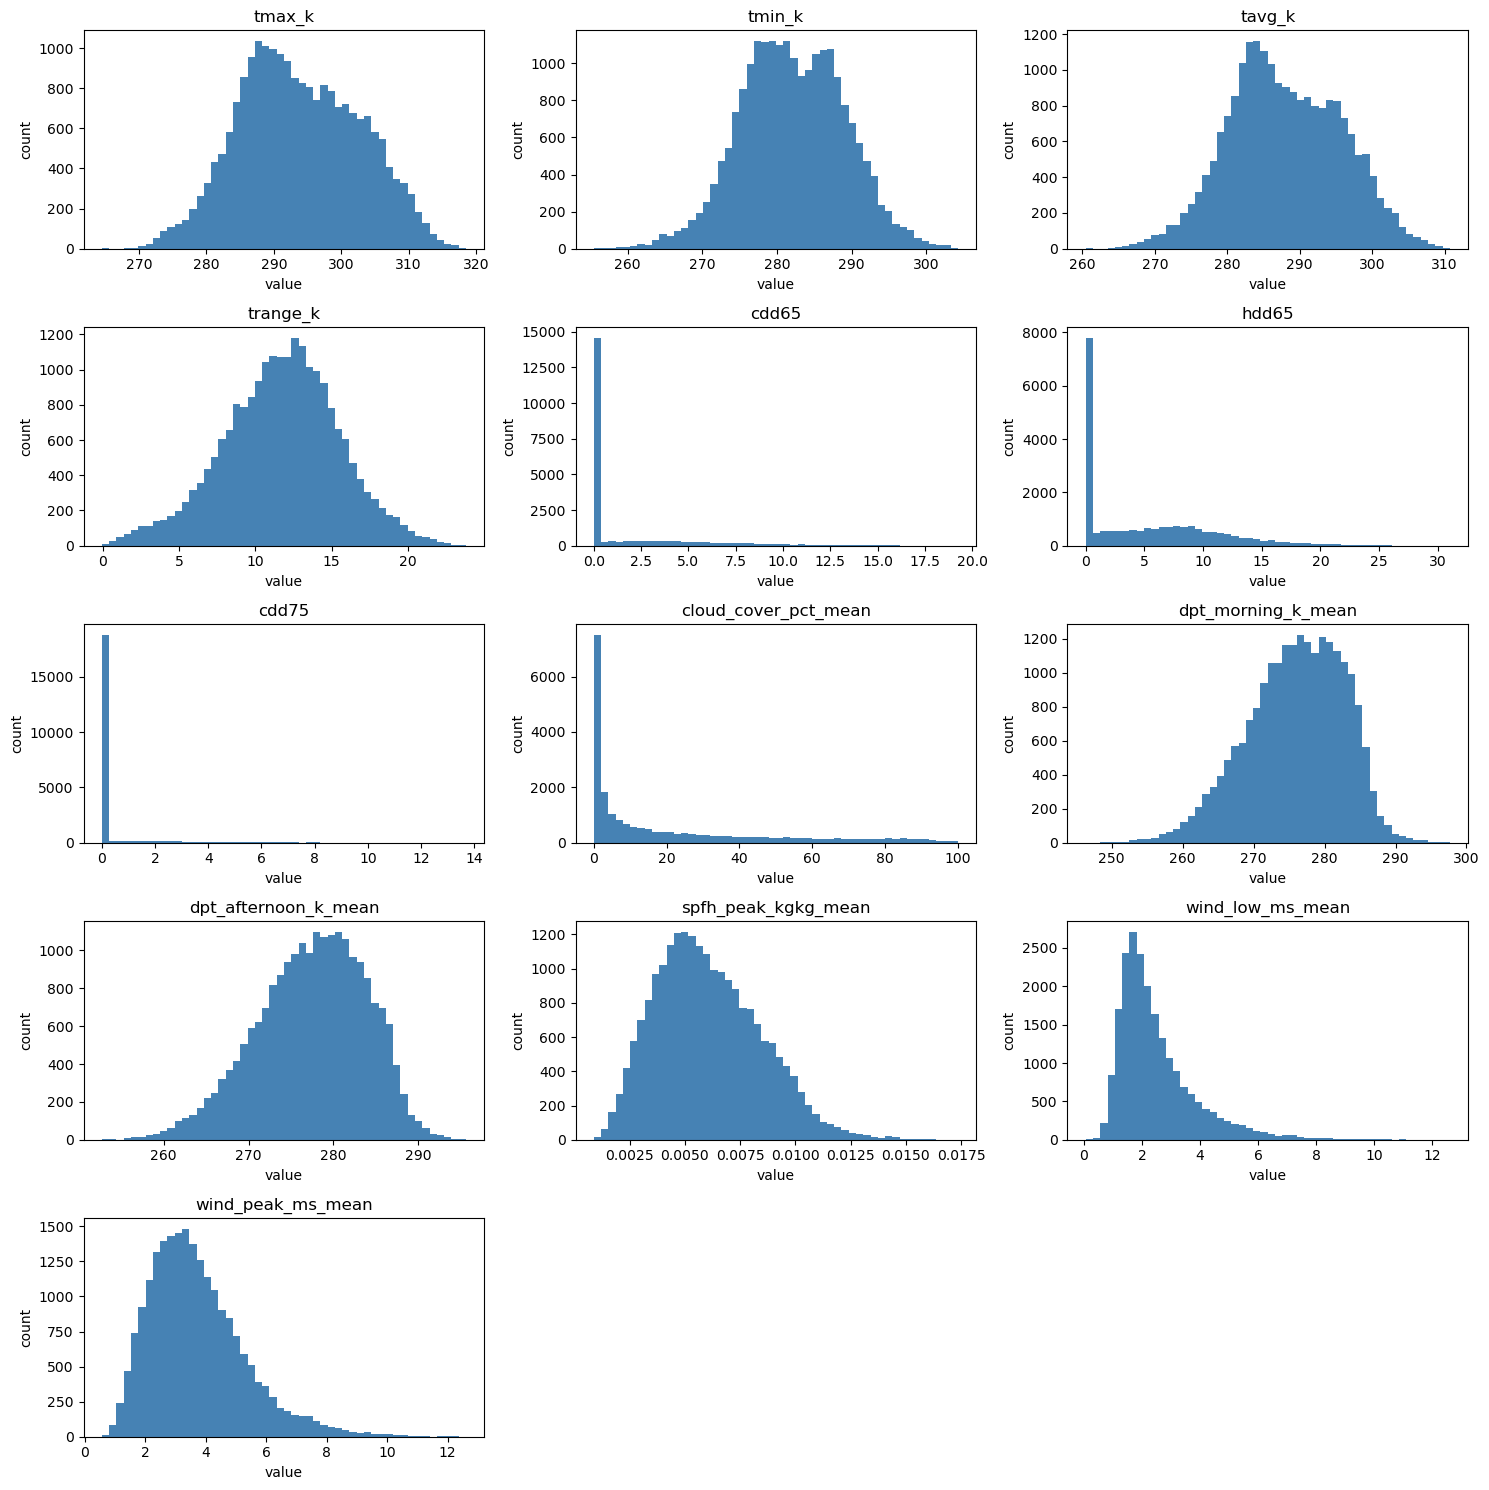

In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dataset_histograms(ds, cols=3, bins=50):
    vars = list(ds.data_vars)
    rows = -(-len(vars) // cols)  # ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
    axes = axes.flatten()
    
    for i, var in enumerate(vars):
        data = ds[var].values.flatten()
        data = data[~np.isnan(data)]
        axes[i].hist(data, bins=bins, color='steelblue', edgecolor='none')
        axes[i].set_title(var)
        axes[i].set_xlabel('value')
        axes[i].set_ylabel('count')
    
    # hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_dataset_histograms(feat)

In [ ]:
# train = feat.to_dataframe().reset_index()
# train.head()

In [ ]:
# train['hdd65'].hist()

## ADD POPULATION INFORMATION

In [42]:
pop = xr.open_zarr("processed/worldpop_population_2019_2021.zarr", consolidated=False)
pop_2020 = pop["population"].sel(year=2020)
pop_2020

<xarray.DataArray 'population' (y: 535, x: 457)> Size: 978kB
dask.array<getitem, shape=(535, 457), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>
Coordinates:
    year     int32 4B 2020
Dimensions without coordinates: y, x
Attributes:
    aggregation:  nearest_urma_cell_center_sum
    source:       WorldPop R2025A 1km_ua constrained (CA clipped)
    units:        persons

## IMPORT 2020 POPULATION DATA TO PREVENT LEAKAGE

In [43]:
def county_pop_weighted_mean(da, county, population):
    """
    da: DataArray (date, y, x) -> one single feature
    county: DataArray (y, x)
    population: DataArray (y, x)  -> 2020 baseline
    """
    da1 = da.stack(cell=("y", "x"))
    county1 = county.stack(cell=("y", "x")) # reshape into 1d for joining later
    pop1 = population.stack(cell=("y", "x")) 

    da1 = da1.assign_coords(
        county=("cell", county1.data),
        population=("cell", pop1.data)
    )

    # Remove null counties
    da1 = da1.where(da1["county"].notnull())

    weighted_sum = (
        (da1 * da1["population"])
        .groupby("county")
        .sum(dim="cell")
    )

    pop_sum = (
        da1["population"]
        .groupby("county")
        .sum(dim="cell")
    )

    return weighted_sum / pop_sum


## ADD POPULATION WEIGHTED FEATURES

In [44]:
feat["tmax_k_pop"] = county_pop_weighted_mean(ds["t2m_max_k"], county, pop_2020)
feat["tmin_k_pop"] = county_pop_weighted_mean(ds["t2m_min_k"], county, pop_2020)

feat["cloud_cover_pct_pop"] = county_pop_weighted_mean(ds["cloud_cover_pct"], county, pop_2020)
feat["wind_peak_ms_pop"] = county_pop_weighted_mean(ds["wind_peak_ms"], county, pop_2020)
feat["spfh_peak_kgkg_pop"] = county_pop_weighted_mean(ds["spfh_peak_kgkg"], county, pop_2020)

In [45]:
feat["dpt_morning_k_pop"] = county_pop_weighted_mean(
    ds["dpt_morning_k"], county, pop_2020
)

feat["dpt_afternoon_k_pop"] = county_pop_weighted_mean(
    ds["dpt_afternoon_k"], county, pop_2020
)

feat["wind_low_ms_pop"] = county_pop_weighted_mean(
    ds["wind_low_ms"], county, pop_2020
)



## Population weighted HDD/CDD

In [46]:
base_k = (65 - 32) * 5/9 + 273.15

In [47]:
tavg = (ds["t2m_max_k"] + ds["t2m_min_k"]) / 2

CDD_grid = (tavg - base_k).clip(min=0)
HDD_grid = (base_k - tavg).clip(min=0)


In [48]:
feat["cdd65_pop"] = county_pop_weighted_mean(
    CDD_grid, county, pop_2020
)

feat["hdd65_pop"] = county_pop_weighted_mean(
    HDD_grid, county, pop_2020
)

In [49]:
base75_k = (75 - 32) * 5/9 + 273.15

CDD75_grid = (tavg - base75_k).clip(min=0)

feat["cdd75_pop"] = county_pop_weighted_mean(
    CDD75_grid, county, pop_2020
)


In [51]:
varibs = len(feat.data_vars)
print(f'Should be 24:{varibs}')

Should be 24:24


In [52]:
dataset_minmax_df(feat)

,variable,min,max
0,tmax_k,264.4911,318.5015
1,tmin_k,255.4692,304.2109
2,tavg_k,260.4494,310.7296
3,trange_k,-0.0518,23.7916
4,cdd65,0.0000,19.2462
5,hdd65,0.0000,31.0339
6,cdd75,0.0000,13.6907
7,cloud_cover_pct_mean,0.0000,100.0000
8,dpt_morning_k_mean,246.3214,297.6593
9,dpt_afternoon_k_mean,252.6913,295.6598


## OPTIONAL QC

In [ ]:
# sb = feat.sel(county="Santa Barbara")

In [ ]:
# sb_df = sb.to_dataframe().reset_index()

# sb_df.head()

In [ ]:
# sb_df[["date", "tmax_k","tmax_k_pop","tmin_k","tmin_k_pop","hdd65","hdd65_pop","cdd65","cdd65_pop","cdd75_pop"]].head(10)

In [ ]:
# oct_df = sb_df[sb_df["date"].dt.month == 10]

# oct_df[[
#     "date",
#     "tmax_k","tmax_k_pop",
#     "tmin_k","tmin_k_pop",
#     "hdd65","hdd65_pop",
#     "cdd65","cdd65_pop",
#     "cdd75_pop"
# ]].head(10)


## NON-OPTIONAL QC

In [ ]:
import numpy as np

np.random.seed(42)

n_dates = feat.sizes["date"]
n_sample = int(n_dates * 0.2)

sample_idx = np.random.choice(n_dates, n_sample, replace=False)

feat_sample = feat.isel(date=sample_idx)

feat_sample


In [ ]:
feat_sample = feat_sample.compute()

summary = []

for var in feat_sample.data_vars:
    da = feat_sample[var]
    summary.append({
        "variable": var,
        "min": float(da.min()),
        "max": float(da.max()),
        "null_count": int(da.isnull().sum()),
    })

import pandas as pd
pd.DataFrame(summary).sort_values("variable")


In [ ]:
feat_sample.head()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# numeric_cols = df.select_dtypes(include=np.number).columns

# for col in numeric_cols:
#     plt.figure(figsize=(6,4))
#     df[col].hist(bins=40)
#     plt.title(col)
#     plt.xlabel(col)
#     plt.ylabel("Count")
#     plt.tight_layout()
#     plt.show()


In [ ]:
feat['cdd65_pop'].plot.hist()

## check for nans

In [53]:
for var in feat.data_vars:
    n_nan = int(feat[var].isnull().sum())
    print(f"{var}: {n_nan} NaNs")


tmax_k: 0 NaNs
tmin_k: 0 NaNs
tavg_k: 0 NaNs
trange_k: 0 NaNs
cdd65: 0 NaNs
hdd65: 0 NaNs
cdd75: 0 NaNs
cloud_cover_pct_mean: 0 NaNs
dpt_morning_k_mean: 0 NaNs
dpt_afternoon_k_mean: 0 NaNs
spfh_peak_kgkg_mean: 0 NaNs
wind_low_ms_mean: 0 NaNs
wind_peak_ms_mean: 0 NaNs
tmax_k_pop: 0 NaNs
tmin_k_pop: 0 NaNs
cloud_cover_pct_pop: 0 NaNs
wind_peak_ms_pop: 0 NaNs
spfh_peak_kgkg_pop: 0 NaNs
dpt_morning_k_pop: 0 NaNs
dpt_afternoon_k_pop: 0 NaNs
wind_low_ms_pop: 0 NaNs
cdd65_pop: 0 NaNs
hdd65_pop: 0 NaNs
cdd75_pop: 0 NaNs


In [ ]:
feat

In [ ]:
feat.to_zarr(f'{OUTPUT}_2_23', mode="w")

## TO PARQUET

In [ ]:
ds = xr.open_zarr(OUTPUT, consolidated=False)   # or ds = feat

In [ ]:
ds = ds.chunk({"date": 30})  # or 10, or 50
df = ds.to_dataframe().reset_index()

In [ ]:
df['date'].min

In [ ]:
PARQUET

In [ ]:
df.to_parquet(PARQUET, index=False)
print("Wrote:", PARQUET)

## Parquet Check

In [ ]:
import os

print("Exists:", os.path.exists(PARQUET))
print("Size (MB):", os.path.getsize(PARQUET) / 1e6)

In [ ]:
import pandas as pd

df_check = pd.read_parquet(PARQUET)

print("Shape:", df_check.shape)
print(df_check.head())

In [ ]:
df_check.columns